# Modelling

This notebook trains, evaluates, and compares **7 classifiers** on the preprocessed CKD dataset.

**Input:** Preprocessed `.npy` arrays from `02_Preprocessing.ipynb`  
**Output:** Best model saved to `model/kidney_model.pkl`, full metrics table in `model/model_results.csv`

| # | Model | Notes |
|---|-------|-------|
| 1 | Logistic Regression | Linear baseline |
| 2 | K-Nearest Neighbours | Distance-based |
| 3 | Decision Tree | Interpretable, prone to overfitting |
| 4 | Random Forest | Ensemble — usually strong on tabular data |
| 5 | XGBoost | Gradient boosting — state-of-the-art tabular |
| 6 | Gradient Boosting | Sklearn's native boosting |
| 7 | Support Vector Machine | RBF kernel, highly effective post-scaling |

**Primary metric: ROC-AUC** - best single metric for clinical binary classification.  
**Secondary: Recall (sensitivity)** - missing a CKD patient is more costly than a false alarm.

## 1 - Imports and Setup

In [1]:
import sys
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Add src/ to path
sys.path.append(str(Path("../src").resolve()))

from config import (
    MODEL_DIR,
    MODEL_PATH,
    MODEL_RESULTS_PATH,
    FEATURE_PATH,
    VIZ_DIR,
    FIG_DPI,
    RANDOM_STATE,
    KNN_PARAMS,
    SVM_PARAMS,
    DECISION_TREE_PARAMS,
    RANDOM_FOREST_PARAMS,
    XGB_PARAMS,
    GRADIENT_BOOSTING_PARAMS,
    LOGISTIC_REGRESSION_PARAMS,
)
from evaluate import (
    get_metrics,
    print_classification_report,
    plot_all_confusion_matrices,
    plot_roc_curves,
    plot_feature_importance,
    build_results_table,
    plot_model_comparison,
)

plt.rcParams.update({"figure.dpi": FIG_DPI, "font.size": 11})
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


## 2 - Load Preprocessed Data

Load the `.npy` arrays saved by `02_Preprocessing.ipynb`.  
These are already imputed, encoded, and scaled — ready for model training.

In [2]:
X_train = np.load(MODEL_DIR / "X_train_sc.npy")
X_test  = np.load(MODEL_DIR / "X_test_sc.npy")
y_train = np.load(MODEL_DIR / "y_train.npy")
y_test  = np.load(MODEL_DIR / "y_test.npy")

with open(FEATURE_PATH) as f:
    feature_names = json.load(f)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"Features: {len(feature_names)}  -  {feature_names}")
print(f"\nClass balance in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    label = "CKD" if u == 1 else "Not CKD"
    print(f"  {label} ({int(u)}): {c} samples")

X_train : (320, 24)   y_train : (320,)
X_test  : (80, 24)    y_test  : (80,)
Features: 24  -  ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia']

Class balance in test set:
  Not CKD (0): 30 samples
  CKD (1): 50 samples


## 3 - Define Models

All hyperparameters come from `config.py` — no magic numbers in the notebook.

In [3]:
models = {
    "Logistic Regression":  LogisticRegression(**LOGISTIC_REGRESSION_PARAMS),
    "KNN":                  KNeighborsClassifier(**KNN_PARAMS),
    "Decision Tree":        DecisionTreeClassifier(**DECISION_TREE_PARAMS),
    "Random Forest":        RandomForestClassifier(**RANDOM_FOREST_PARAMS),
    "XGBoost":              XGBClassifier(**XGB_PARAMS),
    "Gradient Boosting":    GradientBoostingClassifier(**GRADIENT_BOOSTING_PARAMS),
    "SVM":                  SVC(**SVM_PARAMS),
}

print(f"Models registered: {list(models.keys())}")

Models registered: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'SVM']


## 4 - Cross-Validation

Before touching the test set, we use **5-fold stratified cross-validation** on the training data.

> **Why CV before test evaluation?**  
> CV gives an unbiased estimate of generalisation performance using only training data.  
> It also reveals unstable models (high std) vs robust ones (low std).

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

print(f"{'Model':<25} {'CV ROC-AUC':>12}  {'Std':>8}")
print("─" * 50)

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    cv_results.append({"model": name, "cv_mean": scores.mean(), "cv_std": scores.std()})
    print(f"  {name:<23} {scores.mean():.4f}      ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("cv_mean", ascending=False).reset_index(drop=True)
print(f"\nCross-validation complete")

Model                       CV ROC-AUC       Std
──────────────────────────────────────────────────
  Logistic Regression     0.9998      ± 0.0004
  KNN                     0.9818      ± 0.0154
  Decision Tree           0.9610      ± 0.0280
  Random Forest           0.9990      ± 0.0021
  XGBoost                 0.9902      ± 0.0041
  Gradient Boosting       0.9977      ± 0.0023
  SVM                     0.9998      ± 0.0004

Cross-validation complete


## 5 - Train All Models

Fit every model on the **full training set** (`X_train`, `y_train`).  
The test set remains untouched until evaluation in the next section.

In [5]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"  ✓ {name}")

print("\nAll models trained")

  ✓ Logistic Regression
  ✓ KNN
  ✓ Decision Tree
  ✓ Random Forest
  ✓ XGBoost
  ✓ Gradient Boosting
  ✓ SVM

All models trained


## 6 - Classification Reports

Per-class breakdown: precision, recall, F1 for both **CKD** and **Not CKD**.  
In clinical diagnostics, **recall on CKD (class 1)** is the most critical number — missing a patient is worse than a false alarm.

In [6]:
for name, model in trained_models.items():
    print_classification_report(name, model, X_test, y_test)


══════════════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

 Not CKD (0)       0.91      1.00      0.95        30
     CKD (1)       1.00      0.94      0.97        50

    accuracy                           0.96        80
   macro avg       0.95      0.97      0.96        80
weighted avg       0.97      0.96      0.96        80


══════════════════════════════════════════════════════════
  KNN
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

 Not CKD (0)       0.86      1.00      0.92        30
     CKD (1)       1.00      0.90      0.95        50

    accuracy                           0.94        80
   macro avg       0.93      0.95      0.94        80
weighted avg       0.95      0.94      0.94        80


══════════════════════════════════════════════════════════
  Decision Tree
════

## 7 - Confusion Matrices

A grid of all 7 confusion matrices in one figure.  

| Cell | Meaning | Clinical impact |
|------|---------|----------------|
| Top-left (TN) | Predicted Not CKD, is Not CKD | Correct |
| Top-right (FP) | Predicted CKD, is Not CKD | False alarm |
| Bot-left (FN) | Predicted Not CKD, **is CKD** | Missed patient |
| Bot-right (TP) | Predicted CKD, is CKD | Caught |

We want **FN as close to 0 as possible**.

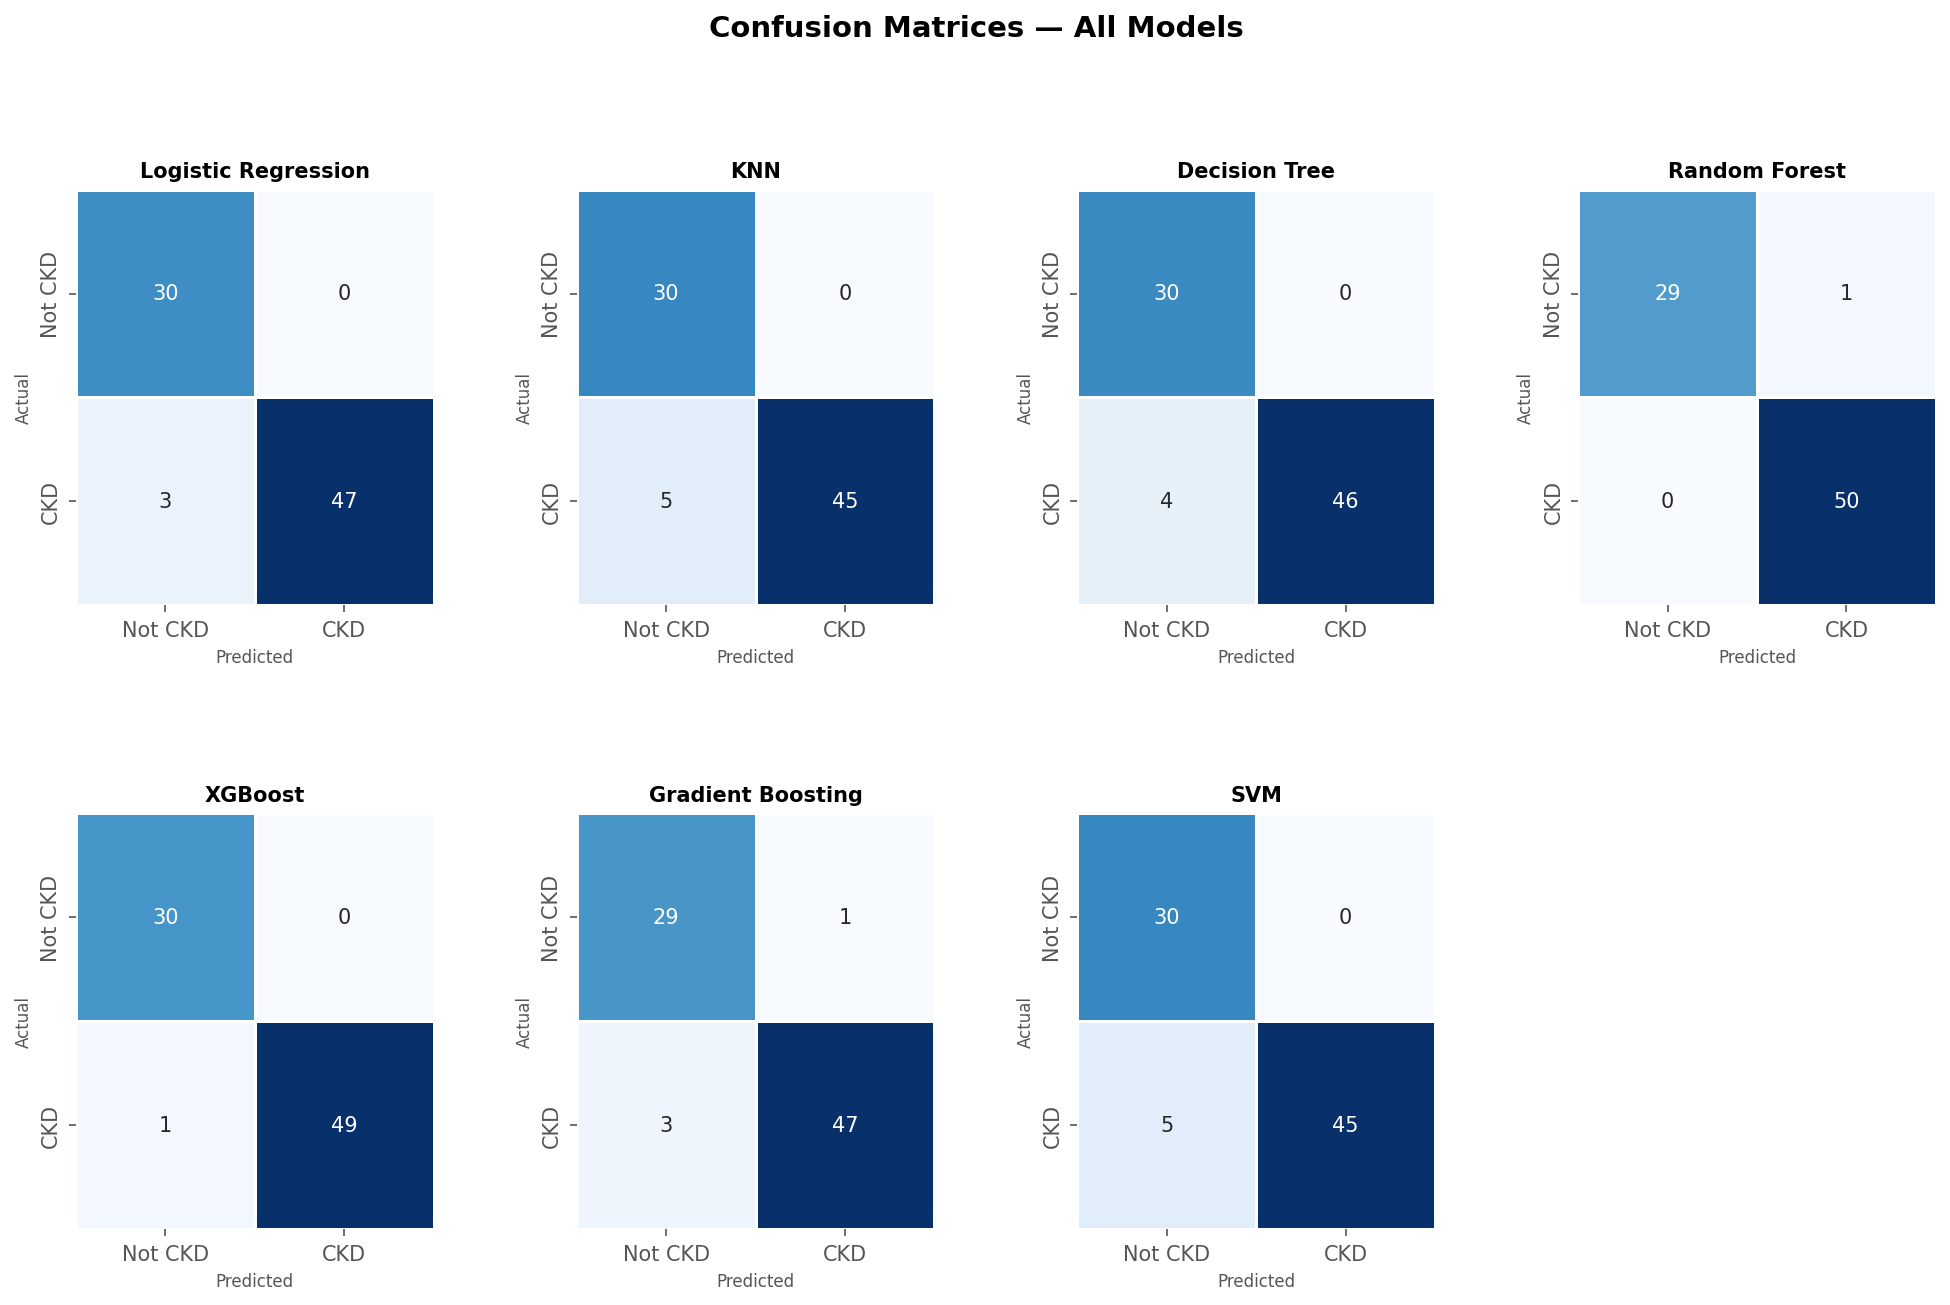

Saved → C:\Users\HP\Desktop\ml-kidney\visualizations\confusion_matrices_all.png


In [7]:
plot_all_confusion_matrices(trained_models, X_test, y_test, save=True)
print(f"Saved → {VIZ_DIR / 'confusion_matrices_all.png'}")

## 8 - ROC Curves

All models plotted on the same axes for direct comparison.  
**AUC = 1.0** is perfect. **AUC = 0.5** is random guessing (the dashed diagonal).

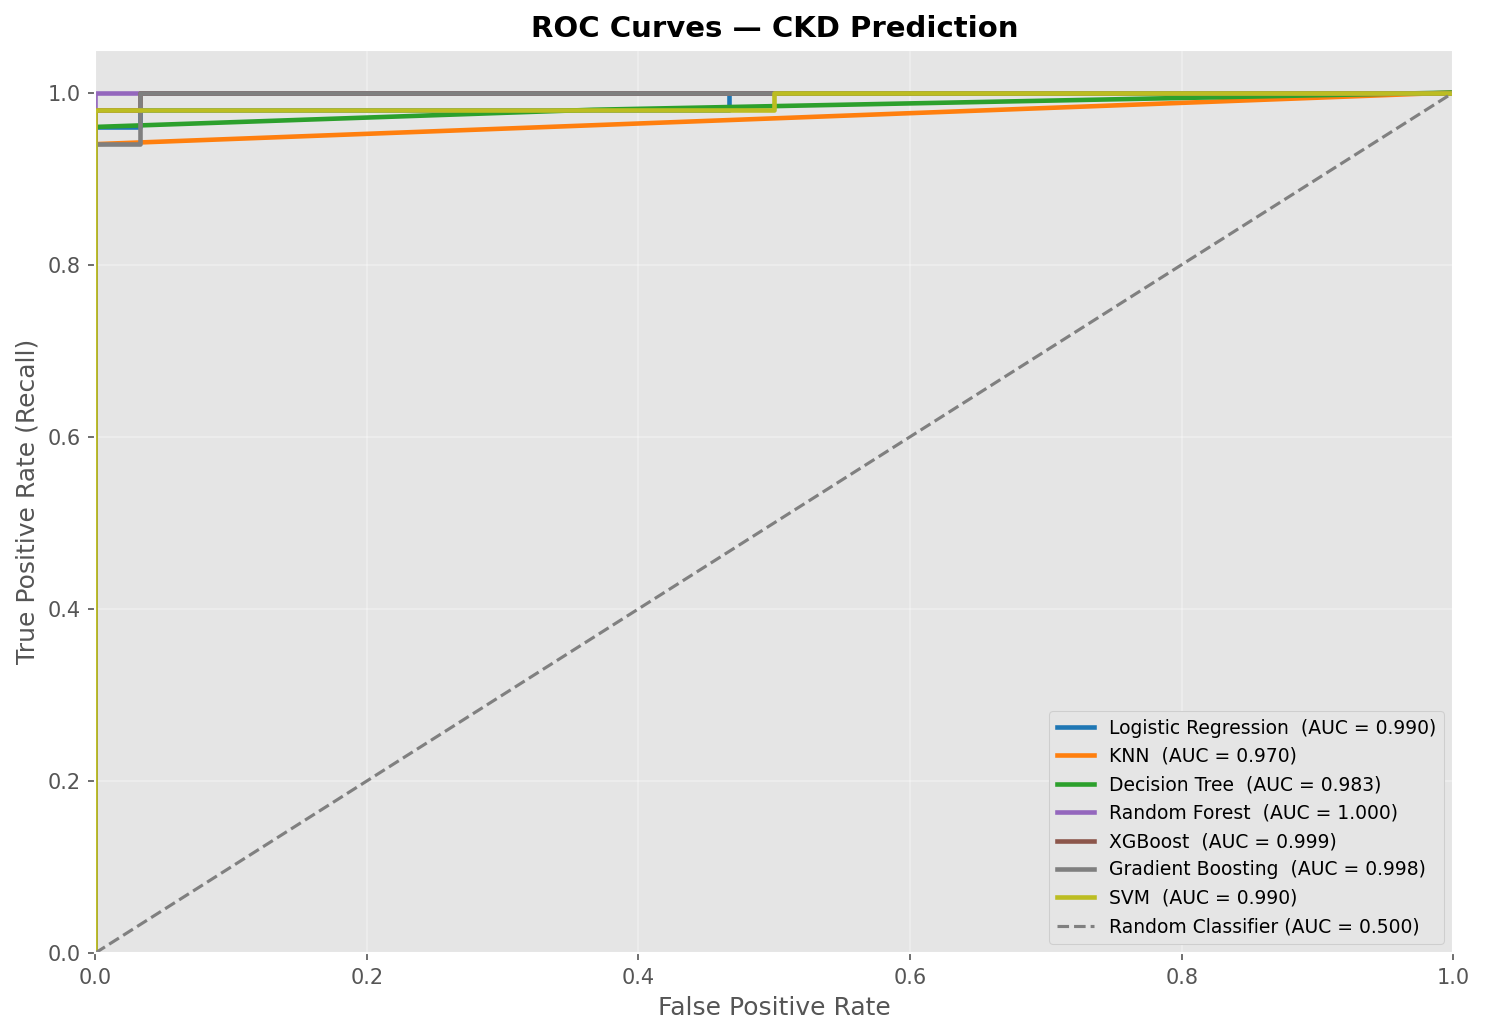

Saved → C:\Users\HP\Desktop\ml-kidney\visualizations\roc_curves.png


In [8]:
plot_roc_curves(trained_models, X_test, y_test, save=True)
print(f"Saved → {VIZ_DIR / 'roc_curves.png'}")

## 9 - Feature Importance (Random Forest)

Which features drive CKD predictions the most?  
Random Forest's Gini importance answers this question reliably on tabular data.

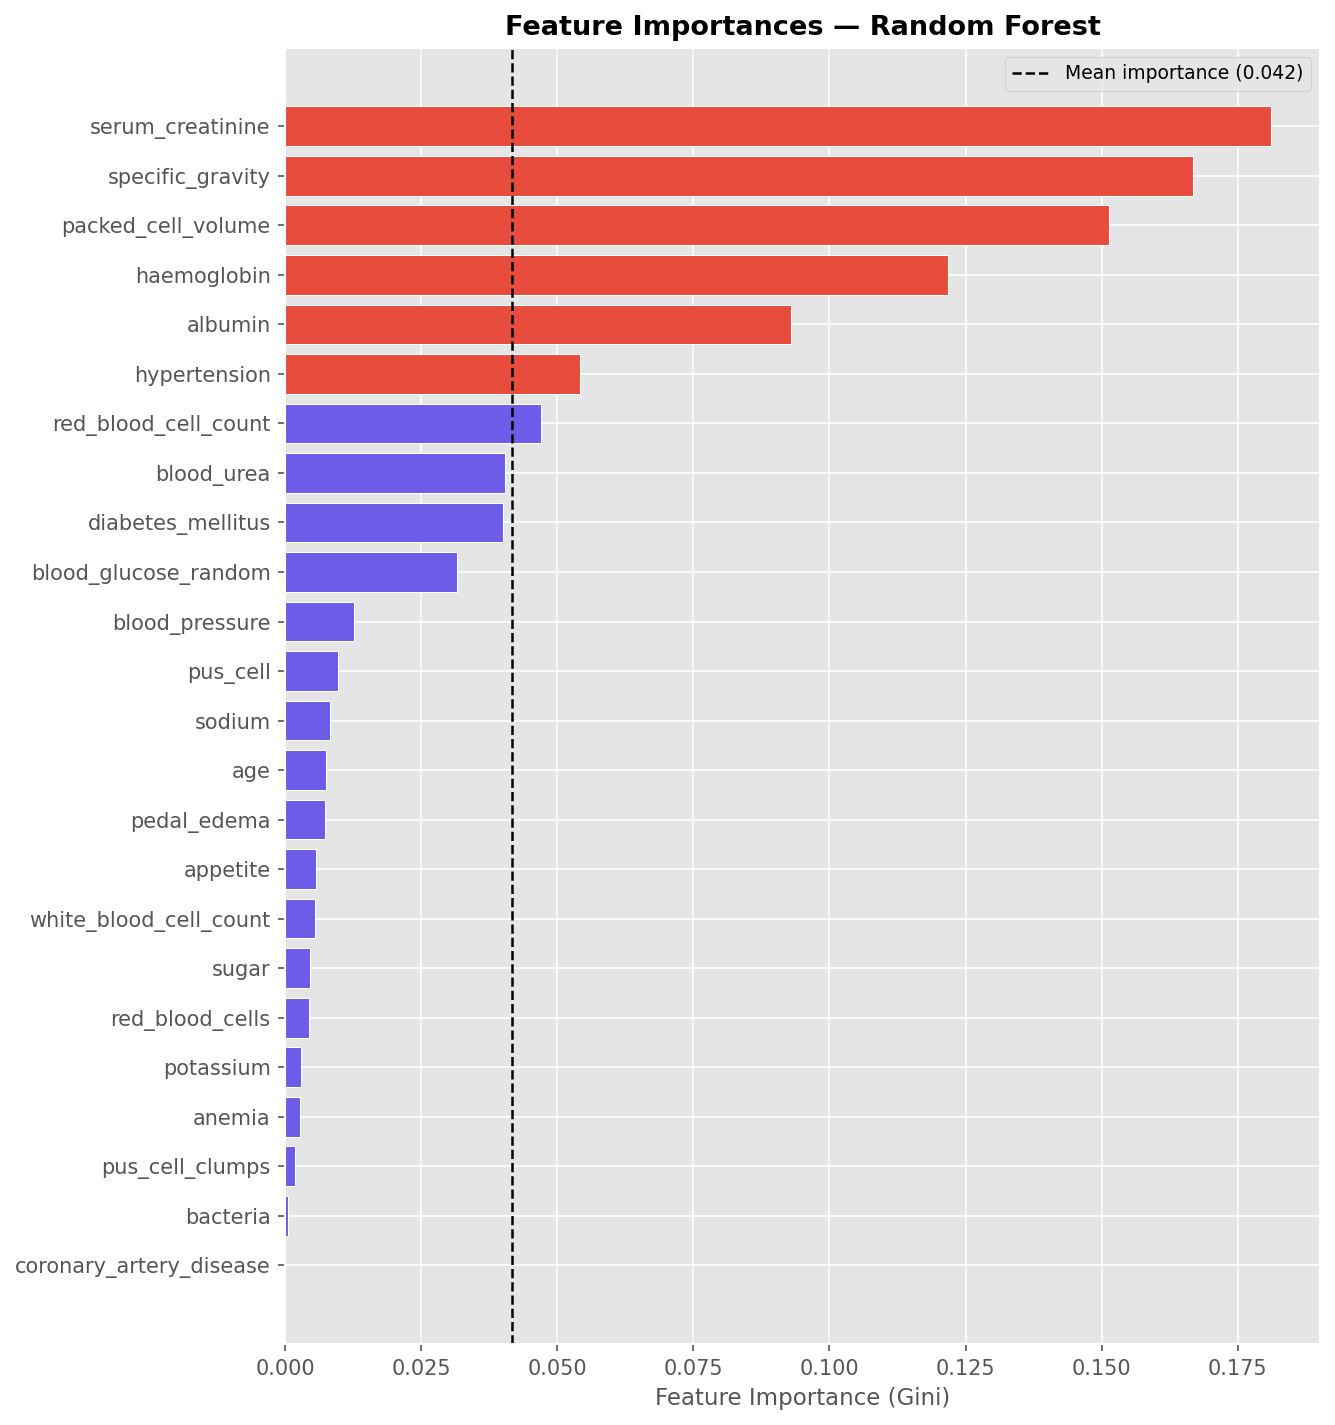

Saved → C:\Users\HP\Desktop\ml-kidney\visualizations\feature_importance_random_forest.png


In [9]:
plot_feature_importance(
    model        = trained_models["Random Forest"],
    feature_names= feature_names,
    model_name   = "Random Forest",
    top_n        = None,   # show all 24 features
    save         = True,
)
print(f"Saved → {VIZ_DIR / 'feature_importance_random_forest.png'}")

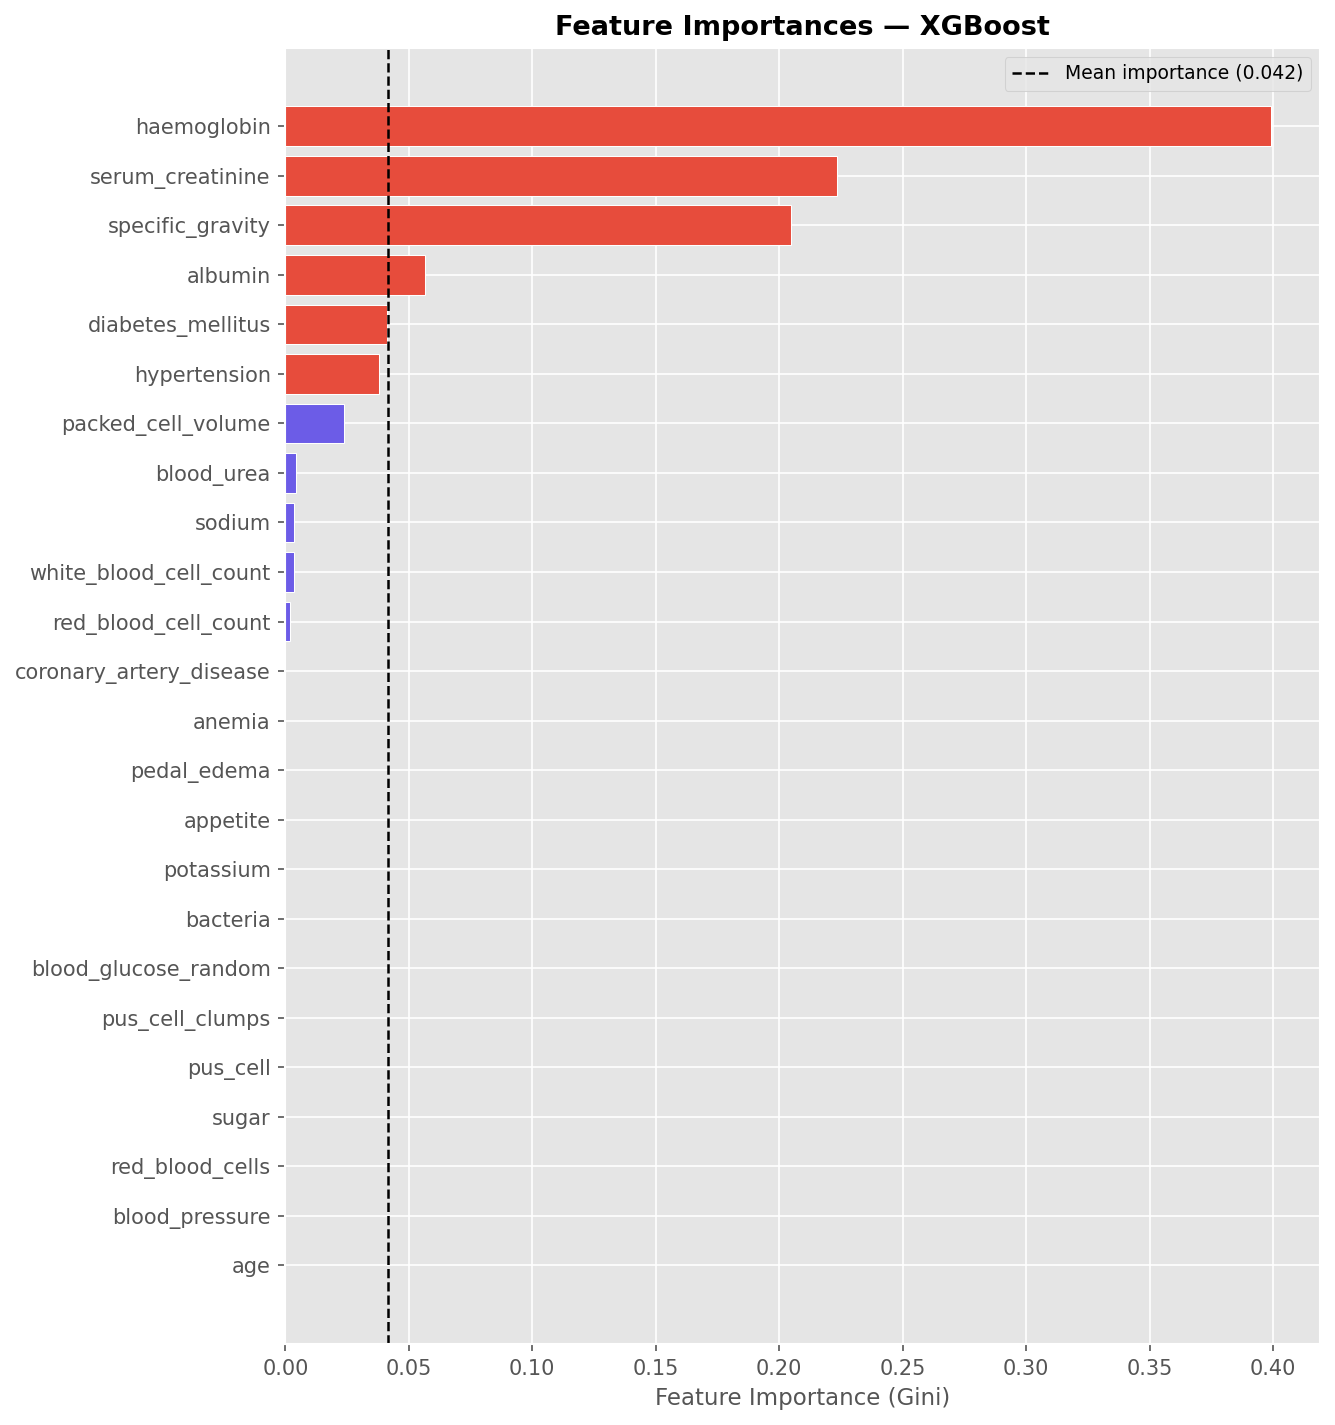

Saved → C:\Users\HP\Desktop\ml-kidney\visualizations\feature_importance_xgboost.png


In [10]:
# Also show XGBoost importance for comparison
plot_feature_importance(
    model        = trained_models["XGBoost"],
    feature_names= feature_names,
    model_name   = "XGBoost",
    top_n        = None,
    save         = True,
)
print(f"Saved → {VIZ_DIR / 'feature_importance_xgboost.png'}")

## 10 - Model Comparison Table & Chart

In [11]:
results_df = build_results_table(trained_models, X_test, y_test)

# Merge in CV scores
results_df = results_df.merge(cv_df[["model", "cv_mean", "cv_std"]], on="model", how="left")

print("Model performance on held-out test set (sorted by ROC-AUC):")
print(results_df.to_string(index=False))

Model performance on held-out test set (sorted by ROC-AUC):
              model  accuracy  precision  recall     f1  roc_auc  cv_mean   cv_std
      Random Forest    0.9875     0.9804    1.00 0.9901   1.0000 0.998958 0.002083
            XGBoost    0.9875     1.0000    0.98 0.9899   0.9993 0.990208 0.004093
  Gradient Boosting    0.9500     0.9792    0.94 0.9592   0.9980 0.997708 0.002320
Logistic Regression    0.9625     1.0000    0.94 0.9691   0.9900 0.999792 0.000417
                SVM    0.9375     1.0000    0.90 0.9474   0.9900 0.999792 0.000417
      Decision Tree    0.9500     1.0000    0.92 0.9583   0.9827 0.961042 0.027979
                KNN    0.9375     1.0000    0.90 0.9474   0.9700 0.981771 0.015387


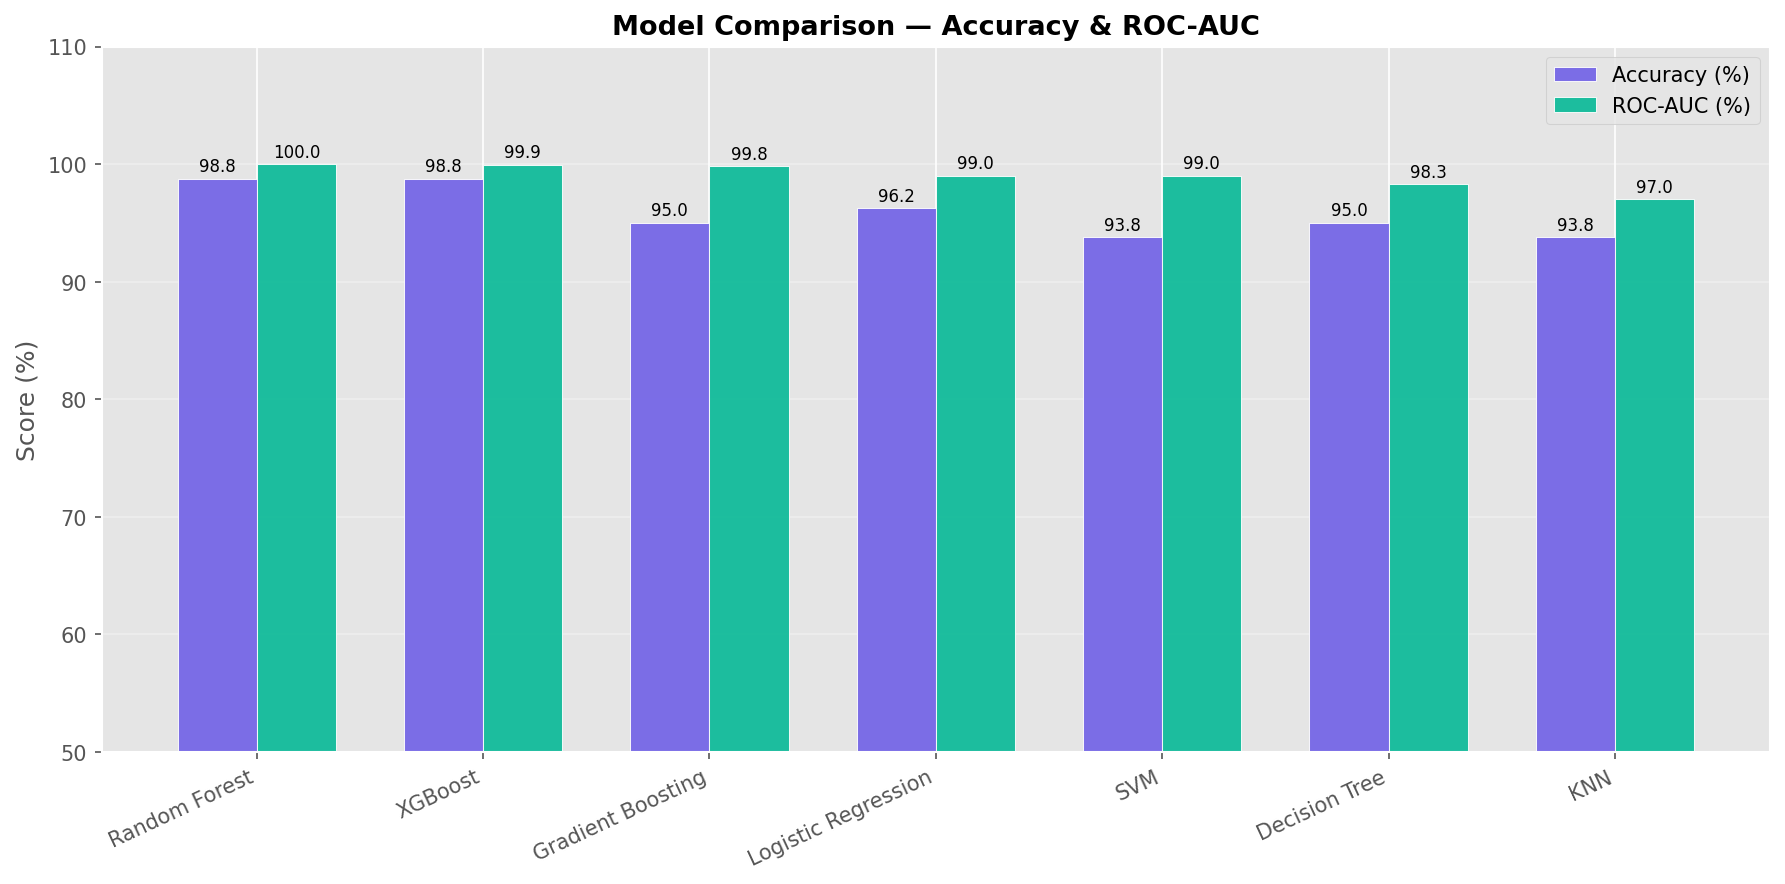

Saved → C:\Users\HP\Desktop\ml-kidney\visualizations\model_comparison.png


In [12]:
plot_model_comparison(results_df, save=True)
print(f"Saved → {VIZ_DIR / 'model_comparison.png'}")

In [13]:
# Save results table so it can be used in the README / API
results_df.to_csv(MODEL_RESULTS_PATH, index=False)
print(f"Results saved → {MODEL_RESULTS_PATH}")

Results saved → C:\Users\HP\Desktop\ml-kidney\model\model_results.csv


## 11 - Select and Save Best Model

Best model = highest ROC-AUC on the test set.  
Saved to `model/kidney_model.pkl` — this is what the API will load.

In [14]:
best_name  = results_df.iloc[0]["model"]
best_model = trained_models[best_name]
best_auc   = results_df.iloc[0]["roc_auc"]
best_acc   = results_df.iloc[0]["accuracy"]

print(f"Best model  : {best_name}")
print(f"ROC-AUC     : {best_auc:.4f}")
print(f"Accuracy    : {best_acc:.4f}")

with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_model, f)

print(f"\nSaved - {MODEL_PATH}")

Best model  : Random Forest
ROC-AUC     : 1.0000
Accuracy    : 0.9875

Saved - C:\Users\HP\Desktop\ml-kidney\model\kidney_model.pkl


## 12 - Sanity Check: Single Prediction

Load the saved model and run a prediction on one test sample to confirm the saved artefact works end-to-end before the API is built.

In [15]:
# Load the saved model fresh from disk
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)

# Pick the first test sample
sample       = X_test[[0]]          # shape (1, n_features)
true_label   = int(y_test[0])
pred_label   = int(loaded_model.predict(sample)[0])
pred_prob    = loaded_model.predict_proba(sample)[0]

label_map = {1: "CKD", 0: "Not CKD"}

print(f"True label       : {label_map[true_label]} ({true_label})")
print(f"Predicted label  : {label_map[pred_label]} ({pred_label})")
print(f"P(Not CKD)       : {pred_prob[0]:.4f}")
print(f"P(CKD)           : {pred_prob[1]:.4f}")
print()

match = "Correct" if pred_label == true_label else "Incorrect"
print(f"Prediction: {match}")

True label       : Not CKD (0)
Predicted label  : Not CKD (0)
P(Not CKD)       : 1.0000
P(CKD)           : 0.0000

Prediction: Correct


## 13 - Summary

| Step | Action | Output |
|------|--------|--------|
| 1 | Load preprocessed arrays | X_train, X_test, y_train, y_test |
| 2 | Define 7 models | Hyperparams from config.py |
| 3 | 5-fold cross-validation | CV ROC-AUC ± std per model |
| 4 | Train all models | 7 fitted classifiers |
| 5 | Classification reports | Precision / Recall / F1 per class |
| 6 | Confusion matrices | Grid of 7 saved to visualizations/ |
| 7 | ROC curves | All models on one plot |
| 8 | Feature importance | RF + XGBoost importances |
| 9 | Model comparison | Table + grouped bar chart |
| 10 | Save best model | `model/kidney_model.pkl` |
| 11 | Sanity check | Single prediction confirmed |